# Coexpression analysis
### Author: Martin Loza
### Date: 25/12/16

Now, let's perform the coexpression analysis

In [21]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
})

# Local variables 
seed = 777
date = "251216"

# Define colors for strand plots
red = "#E41A1C"
blue = "#090a0bff"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

data_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENCODE/selected_gene_pairs/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENCODE/selected_gene_pairs/"

# Local Functions


### Load and setup the data

In [22]:
# load the merged normalized data
expression_data <- read.table(paste0(data_dir, "log_normalized_tpm_selected_lncRNA_TF_genes_251216.tsv"), 
                        header = TRUE, sep = "\t", stringsAsFactors = FALSE)
head(expression_data)[1:5]

,gene_id,chondrocytes_adult,heart_adult,renal_epithelial_adult,liver_adult
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000004848,0.000000000,0.00000000,0.00000000,0.00000000
2,ENSG00000005073,1.011600912,0.00000000,0.73716407,0.00000000
3,ENSG00000005102,0.009950331,0.92821930,0.00000000,0.00000000
4,ENSG00000005436,1.124929597,1.64093658,1.36863943,1.15688120
5,ENSG00000005513,0.254642218,0.04879016,0.03922071,0.01980263
6,ENSG00000005801,0.887891257,1.60140574,2.18154676,0.90421815


Load the lncRNA-TF gene pairs

In [23]:
gene_pairs_file <- "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/human_unique_lncRNA_TF_pairs_10000bp_251215.tsv"
# Load the unique gene pairs data
gene_pairs <- read.table(gene_pairs_file, sep = "\t", header = TRUE, comment.char = "", fill = TRUE, row.names = NULL)
dim(gene_pairs)
head(gene_pairs,2)

[1] 1978   18

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF,abs_strand_distance,ncrna_gene_id,pcg_gene_id,gene_pair_id,gene_name_pair_id
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>,<int>,<chr>,<chr>,<chr>,<chr>
1,11,ENST00000381363,2140644,IGF2-AS,1,lncRNA,ENST00000643349,unnamed,2149603,8959,8959,ZBTB,TRUE,8959,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779,IGF2-AS_unnamed
2,11,ENST00000833483,61756482,MYRF-AS1,-1,lncRNA,ENST00000265460,MYRF,61755389,-1093,1093,NDT80_PhoG,TRUE,1093,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920,MYRF-AS1_MYRF


We don't have expression data of all gene pairs, let's annotate the genes and then select only those with expression of both lncRNA and TF genes

In [24]:
colnames(gene_pairs)    

[1] "chromosome"          "ncRNA_id"            "ncrna_tss"          
 [4] "ncrna_gene_name"     "ncrna_strand"        "gene_biotype"       
 [7] "pcg_id"              "pcg_gene_name"       "pcg_tss"            
[10] "dna_distance"        "strand_distance"     "Family"             
[13] "is_TF"               "abs_strand_distance" "ncrna_gene_id"      
[16] "pcg_gene_id"         "gene_pair_id"        "gene_name_pair_id"

In [25]:
# select columns of interest
sel_cols <- c('ncrna_gene_id', 'pcg_gene_id', 'gene_pair_id') 
expression_gene_pairs <- gene_pairs %>%
    select(all_of(sel_cols)) %>%
    rename(lncRNA_gene_id = ncrna_gene_id,
              TF_gene_id = pcg_gene_id)
head(expression_gene_pairs,2)

,lncRNA_gene_id,TF_gene_id,gene_pair_id
,<chr>,<chr>,<chr>
1,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779
2,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920


Let's transfer the expression information by of gene pairs

In [26]:
# transfer expression information of the lncRNA genes
tmp_expression_data <- expression_data %>%
            rename_with(~ paste0("lncRNA_", .), everything())         
expression_gene_pairs <- expression_gene_pairs %>%
    left_join(tmp_expression_data, by = c("lncRNA_gene_id" = "lncRNA_gene_id"))

# transfer expression information of the TF genes
tmp_expression_data <- expression_data %>%
            rename_with(~ paste0("TF_", .), everything())   
expression_gene_pairs <- expression_gene_pairs %>%
    left_join(tmp_expression_data, by = c("TF_gene_id" = "TF_gene_id"))

head(expression_gene_pairs,2)


,lncRNA_gene_id,TF_gene_id,gene_pair_id,lncRNA_chondrocytes_adult,lncRNA_heart_adult,lncRNA_renal_epithelial_adult,lncRNA_liver_adult,lncRNA_osteoblasts_adult,lncRNA_cardiac_fibroblasts_adult,lncRNA_ovary_adult,⋯,TF_aorta_adult,TF_uterus_adult,TF_tongue_embryonic,TF_frontal_cortex_embryonic,TF_spinal_cord_embryonic,TF_eye_embryonic,TF_stomach_embryonic,TF_lung_embryonic,TF_liver_embryonic,TF_kidney_epithelial_embryonic
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779,0,0.009950331,0.0000000,0.01980263,0.009950331,0,0,⋯,0,0.0000000,0.7793249,0.01980263,0.2700271,0.1310283,0.000000,0.00000,0.2926696,0.000000
2,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920,0,0.000000000,0.0295588,0.02955880,0.000000000,0,0,⋯,0,0.2231436,0.1310283,0.01980263,0.8628900,1.5368672,1.609438,2.74084,0.5653138,1.451614


Select only gene pairs with expression data of both lncRNA and Tf genes

In [27]:
# Select only pairs of genes which have expression information for both genes
# These will have NA in a column if expression information is missing for either gene
merged_normalized_selected <- expression_gene_pairs %>%
    filter(!if_any(everything(), is.na))

cat("Final number of gene pairs with expression data for both genes: ", nrow(merged_normalized_selected), "\n")

Final number of gene pairs with expression data for both genes:  979 


In [28]:
head(expression_gene_pairs,2)

,lncRNA_gene_id,TF_gene_id,gene_pair_id,lncRNA_chondrocytes_adult,lncRNA_heart_adult,lncRNA_renal_epithelial_adult,lncRNA_liver_adult,lncRNA_osteoblasts_adult,lncRNA_cardiac_fibroblasts_adult,lncRNA_ovary_adult,⋯,TF_aorta_adult,TF_uterus_adult,TF_tongue_embryonic,TF_frontal_cortex_embryonic,TF_spinal_cord_embryonic,TF_eye_embryonic,TF_stomach_embryonic,TF_lung_embryonic,TF_liver_embryonic,TF_kidney_epithelial_embryonic
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779,0,0.009950331,0.0000000,0.01980263,0.009950331,0,0,⋯,0,0.0000000,0.7793249,0.01980263,0.2700271,0.1310283,0.000000,0.00000,0.2926696,0.000000
2,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920,0,0.000000000,0.0295588,0.02955880,0.000000000,0,0,⋯,0,0.2231436,0.1310283,0.01980263,0.8628900,1.5368672,1.609438,2.74084,0.5653138,1.451614


### Coexpression analysis

In [29]:
# Extract expression matrices for lncRNA and TF genes
lncRNA_expression <- merged_normalized_selected %>%
    select(starts_with("lncRNA_") & !c(lncRNA_gene_id)) %>%
    as.matrix()

TF_expression <- merged_normalized_selected %>%
    select(starts_with("TF_") & !c(TF_gene_id)) %>%
    as.matrix()

# Check dimensions
cat("lncRNA expression matrix dimensions: ", dim(lncRNA_expression), "\n")
cat("TF expression matrix dimensions: ", dim(TF_expression), "\n")

lncRNA expression matrix dimensions:  979 20 
TF expression matrix dimensions:  979 20 
TF expression matrix dimensions:  979 20 


In [30]:
# Calculate Pearson and Spearman correlation and p-values for each gene pair
n_pairs <- nrow(merged_normalized_selected)
coexpression_results <- data.frame(
    gene_pair_id = merged_normalized_selected$gene_pair_id,
    lncRNA_gene_id = merged_normalized_selected$lncRNA_gene_id,
    TF_gene_id = merged_normalized_selected$TF_gene_id,
    pearson_correlation = numeric(n_pairs),
    pearson_pvalue = numeric(n_pairs),
    spearman_correlation = numeric(n_pairs),
    spearman_pvalue = numeric(n_pairs),
    n_samples = integer(n_pairs)
)

# Calculate correlation for each gene pair
for (i in 1:n_pairs) {
    lncRNA_expr <- as.numeric(lncRNA_expression[i, ])
    TF_expr <- as.numeric(TF_expression[i, ])
    
    # Perform Pearson correlation test
    pearson_test <- cor.test(lncRNA_expr, TF_expr, method = "pearson")
    coexpression_results$pearson_correlation[i] <- pearson_test$estimate
    coexpression_results$pearson_pvalue[i] <- pearson_test$p.value
    
    # Perform Spearman correlation test
    spearman_test <- cor.test(lncRNA_expr, TF_expr, method = "spearman", exact = FALSE)
    coexpression_results$spearman_correlation[i] <- spearman_test$estimate
    coexpression_results$spearman_pvalue[i] <- spearman_test$p.value
    
    coexpression_results$n_samples[i] <- sum(!is.na(lncRNA_expr) & !is.na(TF_expr))
}

cat("Coexpression analysis completed for", n_pairs, "gene pairs\n")

Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(rank(x), rank(y)):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(rank(x), rank(y)):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(rank(x), rank(y)):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(rank(x), rank(y)):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(rank(x), rank(y)):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(rank(x), rank(y)):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(rank(x), rank(y)):
“the standard deviation is zero”
Warning message in cor(x, y):
“the

Coexpression analysis completed for 979 gene pairs


In [31]:
# Apply FDR correction (Benjamini-Hochberg method) for both Pearson and Spearman
coexpression_results$pearson_fdr <- p.adjust(coexpression_results$pearson_pvalue, method = "fdr")
coexpression_results$spearman_fdr <- p.adjust(coexpression_results$spearman_pvalue, method = "fdr")

# Add significance flags
coexpression_results$pearson_significant_0.05 <- coexpression_results$pearson_fdr < 0.05
coexpression_results$pearson_significant_0.01 <- coexpression_results$pearson_fdr < 0.01
coexpression_results$spearman_significant_0.05 <- coexpression_results$spearman_fdr < 0.05
coexpression_results$spearman_significant_0.01 <- coexpression_results$spearman_fdr < 0.01

# Display summary statistics
cat("\n=== Coexpression Analysis Summary ===\n")
cat("Total gene pairs analyzed:", nrow(coexpression_results), "\n\n")

cat("--- Pearson Correlation ---\n")
cat("Mean correlation:", round(mean(coexpression_results$pearson_correlation, na.rm = TRUE), 3), "\n")
cat("Median correlation:", round(median(coexpression_results$pearson_correlation, na.rm = TRUE), 3), "\n")
cat("Significant pairs (FDR < 0.05):", sum(coexpression_results$pearson_significant_0.05, na.rm = TRUE), "\n")
cat("Significant pairs (FDR < 0.01):", sum(coexpression_results$pearson_significant_0.01, na.rm = TRUE), "\n")
cat("Positively correlated (r > 0):", sum(coexpression_results$pearson_correlation > 0, na.rm = TRUE), "\n")
cat("Negatively correlated (r < 0):", sum(coexpression_results$pearson_correlation < 0, na.rm = TRUE), "\n\n")

cat("--- Spearman Correlation ---\n")
cat("Mean correlation:", round(mean(coexpression_results$spearman_correlation, na.rm = TRUE), 3), "\n")
cat("Median correlation:", round(median(coexpression_results$spearman_correlation, na.rm = TRUE), 3), "\n")
cat("Significant pairs (FDR < 0.05):", sum(coexpression_results$spearman_significant_0.05, na.rm = TRUE), "\n")
cat("Significant pairs (FDR < 0.01):", sum(coexpression_results$spearman_significant_0.01, na.rm = TRUE), "\n")
cat("Positively correlated (rho > 0):", sum(coexpression_results$spearman_correlation > 0, na.rm = TRUE), "\n")
cat("Negatively correlated (rho < 0):", sum(coexpression_results$spearman_correlation < 0, na.rm = TRUE), "\n")


=== Coexpression Analysis Summary ===
Total gene pairs analyzed: 979 

--- Pearson Correlation ---
Mean correlation: 0.461 
Median correlation: 0.509 
Significant pairs (FDR < 0.05): 397 
Total gene pairs analyzed: 979 

--- Pearson Correlation ---
Mean correlation: 0.461 
Median correlation: 0.509 
Significant pairs (FDR < 0.05): 397 
Significant pairs (FDR < 0.01): 312 
Positively correlated (r > 0): 673 
Negatively correlated (r < 0): 104 

--- Spearman Correlation ---
Mean correlation: 0.406 
Median correlation: 0.453 
Significant pairs (FDR < 0.01): 312 
Positively correlated (r > 0): 673 
Negatively correlated (r < 0): 104 

--- Spearman Correlation ---
Mean correlation: 0.406 
Median correlation: 0.453 
Significant pairs (FDR < 0.05): 334 
Significant pairs (FDR < 0.01): 205 
Positively correlated (rho > 0): 677 
Negatively correlated (rho < 0): 100 
Significant pairs (FDR < 0.05): 334 
Significant pairs (FDR < 0.01): 205 
Positively correlated (rho > 0): 677 
Negatively correl

In [32]:
# Display top results sorted by Pearson correlation strength
cat("\n=== Top 10 Gene Pairs by Pearson Correlation ===\n")
head(coexpression_results %>% arrange(desc(abs(pearson_correlation))), 10)


=== Top 10 Gene Pairs by Pearson Correlation ===


,gene_pair_id,lncRNA_gene_id,TF_gene_id,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue,n_samples,pearson_fdr,spearman_fdr,pearson_significant_0.05,pearson_significant_0.01,spearman_significant_0.05,spearman_significant_0.01
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>
1,ENSG00000253405_ENSG00000106038,ENSG00000253405,ENSG00000106038,1.0000000,0.000000e+00,1.0000000,1.245968e-139,20,0.000000e+00,4.840587e-137,TRUE,TRUE,TRUE,TRUE
2,ENSG00000248550_ENSG00000165588,ENSG00000248550,ENSG00000165588,0.9999956,6.109076e-47,0.6085806,4.406824e-03,20,1.582251e-44,1.456515e-02,TRUE,TRUE,TRUE,FALSE
3,ENSG00000259133_ENSG00000165588,ENSG00000259133,ENSG00000165588,0.9999956,6.109076e-47,0.6085806,4.406824e-03,20,1.582251e-44,1.456515e-02,TRUE,TRUE,TRUE,FALSE
4,ENSG00000253563_ENSG00000136352,ENSG00000253563,ENSG00000136352,0.9999900,9.242999e-44,0.7254763,2.945642e-04,20,1.795452e-41,1.788096e-03,TRUE,TRUE,TRUE,TRUE
5,ENSG00000259439_ENSG00000138083,ENSG00000259439,ENSG00000138083,0.9999869,1.056650e-42,0.8380541,3.978832e-06,20,1.642033e-40,5.945294e-05,TRUE,TRUE,TRUE,TRUE
6,ENSG00000236502_ENSG00000138083,ENSG00000236502,ENSG00000138083,0.9997509,3.499897e-31,1.0000000,0.000000e+00,20,4.532366e-29,0.000000e+00,TRUE,TRUE,TRUE,TRUE
7,ENSG00000229415_ENSG00000136352,ENSG00000229415,ENSG00000136352,0.9996887,2.605287e-30,0.5000000,2.476956e-02,20,2.891868e-28,5.562412e-02,TRUE,TRUE,FALSE,FALSE
8,ENSG00000225156_ENSG00000138083,ENSG00000225156,ENSG00000138083,0.9988602,3.071025e-25,0.5000000,2.476956e-02,20,2.982733e-23,5.562412e-02,TRUE,TRUE,FALSE,FALSE
9,ENSG00000260037_ENSG00000278570,ENSG00000260037,ENSG00000278570,0.9981059,2.959469e-23,0.4448841,4.935594e-02,20,2.555008e-21,9.684234e-02,TRUE,TRUE,FALSE,FALSE


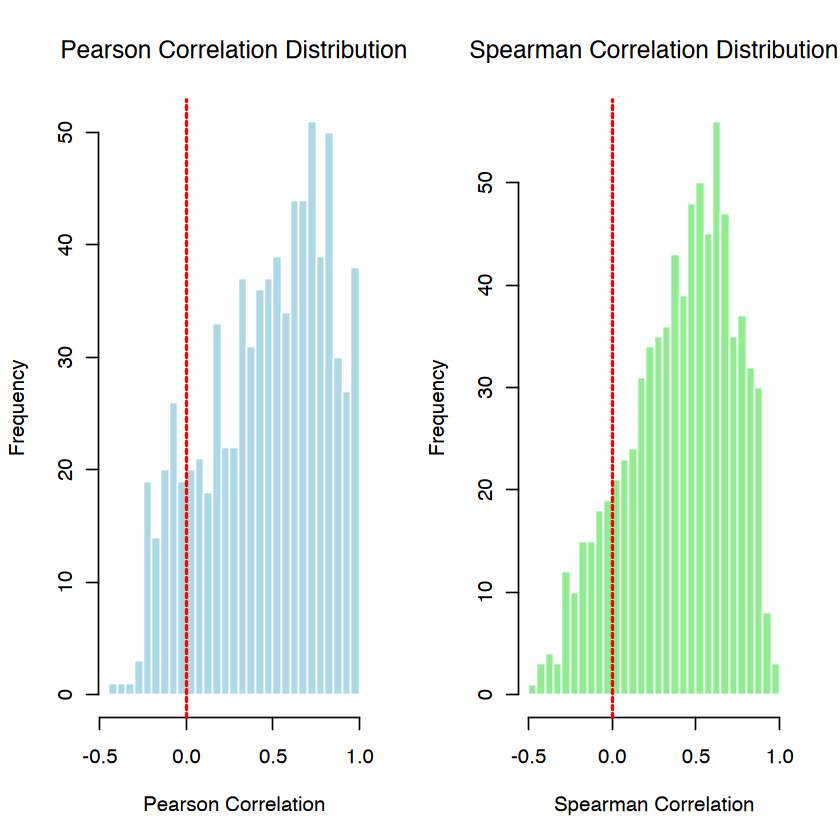

In [33]:
# Distribution of correlation values - Pearson and Spearman
par(mfrow = c(1, 2))

hist(coexpression_results$pearson_correlation, 
     breaks = 50, 
     main = "Pearson Correlation Distribution",
     xlab = "Pearson Correlation",
     col = "lightblue",
     border = "white")
abline(v = 0, col = "red", lty = 2, lwd = 2)

hist(coexpression_results$spearman_correlation, 
     breaks = 50, 
     main = "Spearman Correlation Distribution",
     xlab = "Spearman Correlation",
     col = "lightgreen",
     border = "white")
abline(v = 0, col = "red", lty = 2, lwd = 2)

par(mfrow = c(1, 1))

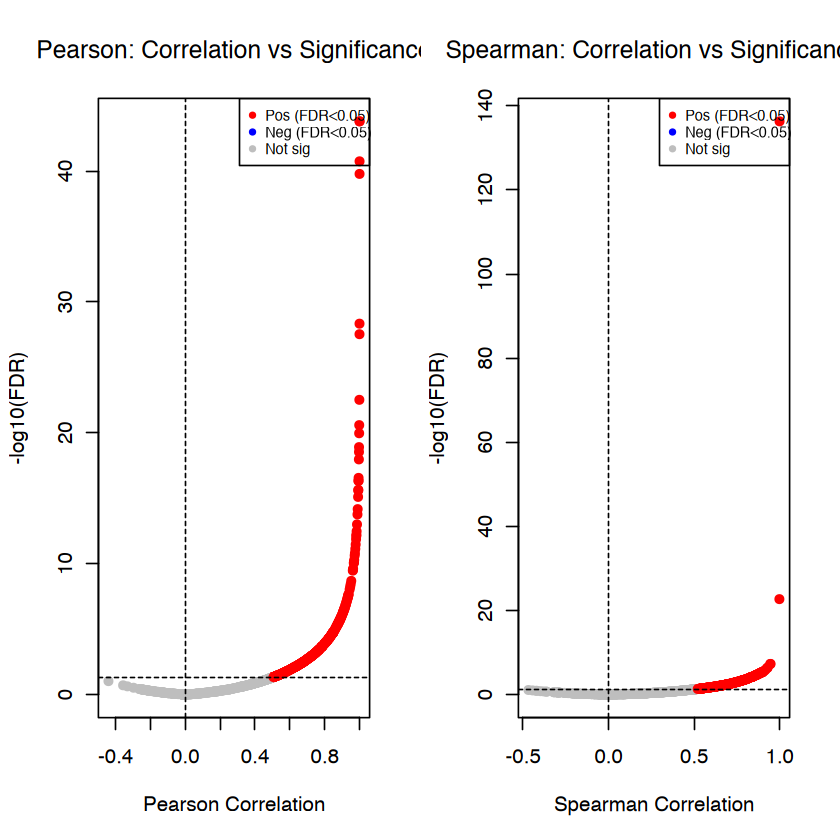

In [34]:
# Volcano plots: correlation vs -log10(FDR) for both Pearson and Spearman
par(mfrow = c(1, 2))

# Pearson volcano plot
plot(coexpression_results$pearson_correlation, 
     -log10(coexpression_results$pearson_fdr),
     pch = 16,
     col = ifelse(coexpression_results$pearson_significant_0.05, 
                  ifelse(coexpression_results$pearson_correlation > 0, "red", "blue"), 
                  "grey"),
     xlab = "Pearson Correlation",
     ylab = "-log10(FDR)",
     main = "Pearson: Correlation vs Significance")
abline(v = 0, col = "black", lty = 2)
abline(h = -log10(0.05), col = "black", lty = 2)
legend("topright", 
       legend = c("Pos (FDR<0.05)", "Neg (FDR<0.05)", "Not sig"),
       col = c("red", "blue", "grey"),
       pch = 16,
       cex = 0.7)

# Spearman volcano plot
plot(coexpression_results$spearman_correlation, 
     -log10(coexpression_results$spearman_fdr),
     pch = 16,
     col = ifelse(coexpression_results$spearman_significant_0.05, 
                  ifelse(coexpression_results$spearman_correlation > 0, "red", "blue"), 
                  "grey"),
     xlab = "Spearman Correlation",
     ylab = "-log10(FDR)",
     main = "Spearman: Correlation vs Significance")
abline(v = 0, col = "black", lty = 2)
abline(h = -log10(0.05), col = "black", lty = 2)
legend("topright", 
       legend = c("Pos (FDR<0.05)", "Neg (FDR<0.05)", "Not sig"),
       col = c("red", "blue", "grey"),
       pch = 16,
       cex = 0.7)

par(mfrow = c(1, 1))

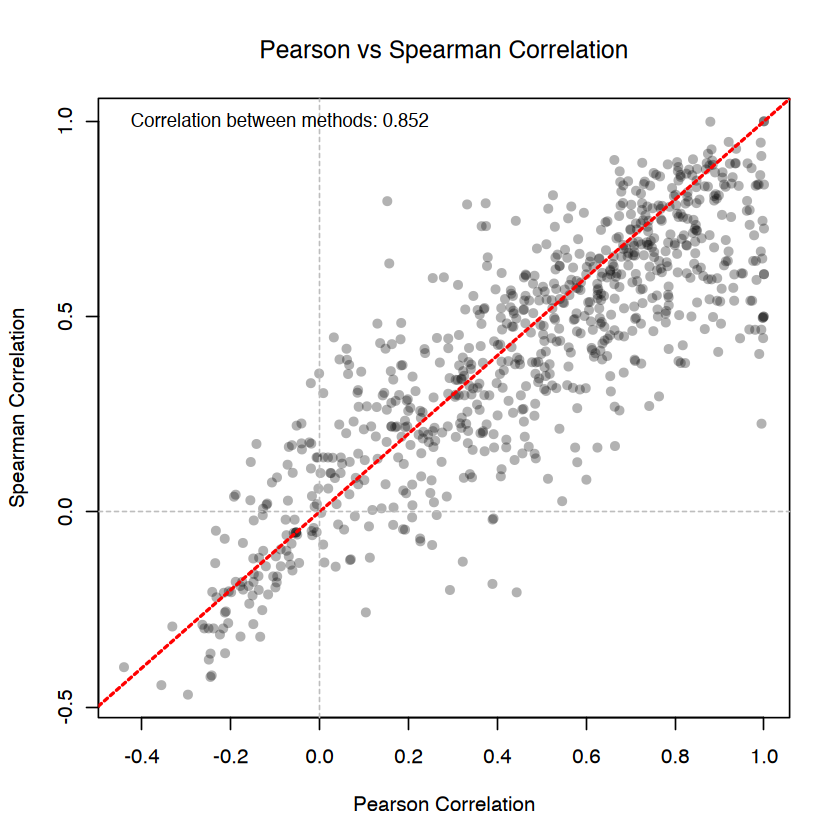

In [35]:
# Comparison: Pearson vs Spearman correlation
plot(coexpression_results$pearson_correlation, 
     coexpression_results$spearman_correlation,
     pch = 16,
     col = rgb(0, 0, 0, 0.3),
     xlab = "Pearson Correlation",
     ylab = "Spearman Correlation",
     main = "Pearson vs Spearman Correlation")
abline(0, 1, col = "red", lty = 2, lwd = 2)
abline(h = 0, col = "grey", lty = 2)
abline(v = 0, col = "grey", lty = 2)

# Calculate correlation between the two methods
method_cor <- cor(coexpression_results$pearson_correlation, 
                  coexpression_results$spearman_correlation,
                  use = "complete.obs")
legend("topleft", 
       legend = paste0("Correlation between methods: ", round(method_cor, 3)),
       bty = "n",
       cex = 0.9)

In [ ]:
# # Save coexpression results
# output_file <- "../Data/ENCODE/coexpression_results_251216.tsv"
# write.table(coexpression_results, 
#             file = output_file, 
#             sep = "\t", 
#             row.names = FALSE, 
#             quote = FALSE)
# cat("Coexpression results saved to:", output_file, "\n")